In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import matplotlib.dates as mdates
import pvlib
from unittest import result

In [2]:
# ── Standort-Koordinaten & Konstanten ─────────────────────────────────────────
LAT, LON, ALT = 46.838, 9.813, 2480   # °N, °E, m ü.M.
TZ = "Europe/Zurich"

RELEVANT_CHANNELS = {
    18: "Front row – Front side",
    22: "Front row – Back side",
     3: "Back row – Front side",
     7: "Back row – Back side",
}
COLORS = {18: "tab:blue", 22: "tab:cyan", 3: "tab:red", 7: "tab:orange"}


# Data loading

In [3]:
# STC-Referenzleistungen
stc_powers = pd.read_csv('../data/raw/STC_Powers.csv', sep=';', decimal=',')

# Mini-PVA: alle Tagesdateien einlesen und kombinieren
files = sorted(glob.glob('../data/raw/mini_pva_daily/*.csv'))
print(f"Gefundene Mini-PVA Tagesdateien: {len(files)}")
minipva = pd.concat([pd.read_csv(f, sep=';', decimal=',') for f in files], ignore_index=True)

# Umweltdaten (Gesamtperiode)
env_data_full = pd.read_csv('../data/raw/environmental_data.csv', sep=';', decimal=',')

# Grosse Anlage (Gesamtperiode)
largeinstallation_full = pd.read_csv('../data/raw/largeInstallation_measurementData.csv', sep=';', decimal=',')

print(minipva.info())
print(env_data_full.info())
print(largeinstallation_full.info())

Gefundene Mini-PVA Tagesdateien: 180


C:\Users\chaen\AppData\Local\Temp\ipykernel_13228\1827201923.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  minipva = pd.concat([pd.read_csv(f, sep=';', decimal=',') for f in files], ignore_index=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951999 entries, 0 to 951998
Data columns (total 15 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID.Results  951999 non-null  float64
 1   mes_date    951999 non-null  object 
 2   ID.Modul    951999 non-null  object 
 3   channel     951999 non-null  object 
 4   U0          951999 non-null  float64
 5   Ik          951999 non-null  float64
 6   Pmpp        951999 non-null  float64
 7   FF          927520 non-null  float64
 8   Ghor        951999 non-null  object 
 9   Tluft       951999 non-null  object 
 10  RA          951999 non-null  object 
 11  MN          951999 non-null  object 
 12  HN          951999 non-null  object 
 13  Res         951999 non-null  object 
 14  mes_time    951999 non-null  object 
dtypes: float64(5), object(10)
memory usage: 108.9+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546561 entries, 0 to 1546560
Data columns (total 5 columns):
 # 

# Data cleaning

In [4]:
# mes_date enthält bereits Datum + Uhrzeit (Format: "10/1/2024 12:00:29 AM")
# mes_time ist redundant → direkt droppen
minipva.drop(columns=['mes_time'], inplace=True)

minipva['mes_date'] = pd.to_datetime(
    minipva['mes_date'],
    format='%m/%d/%Y %I:%M:%S %p',
    errors='coerce'
)

# Numerische Spalten konvertieren
minipva['channel'] = pd.to_numeric(minipva['channel'], errors='coerce').astype('Int64')
minipva['RA'] = pd.to_numeric(minipva['RA'], errors='coerce')
minipva['MN'] = pd.to_numeric(minipva['MN'], errors='coerce')
minipva['HN'] = pd.to_numeric(minipva['HN'], errors='coerce')

# Tluft: "15.1°C " → float
minipva['Tluft'] = (
    minipva['Tluft'].astype(str)
    .str.replace('°C', '', regex=False)
    .str.strip()
    .astype(float)
)

# Ghor: falls String mit Komma als Dezimaltrennzeichen
minipva['Ghor'] = pd.to_numeric(
    minipva['Ghor'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)

# Timestamp-Parsing prüfen
n_failed = minipva['mes_date'].isna().sum()
if n_failed > 0:
    print(f"⚠  {n_failed} Timestamps konnten nicht geparst werden")

# Timezone – ZUERST nach Zeit sortieren, dann lokalisieren
minipva.sort_values('mes_date', inplace=True)
minipva.reset_index(drop=True, inplace=True)

# ambiguous='NaT': DST-Umstellung (27.10.2024 02:00-03:00) → NaT → droppen
minipva['mes_date'] = minipva['mes_date'].dt.tz_localize(
    'Europe/Zurich', ambiguous='NaT', nonexistent='shift_forward'
)
n_ambiguous = minipva['mes_date'].isna().sum()
print(f"Ambiguous timestamps (DST-Umstellung): {n_ambiguous} Zeilen → werden gedroppt")
minipva.dropna(subset=['mes_date'], inplace=True)

# Nach channel + Zeit sortieren
minipva.sort_values(['channel', 'mes_date'], inplace=True)
minipva.reset_index(drop=True, inplace=True)


Ambiguous timestamps (DST-Umstellung): 8 Zeilen → werden gedroppt


In [5]:
# ── MN/RA Bereinigung ─────────────────────────────────────────────────────────

# MN: unsigned 16-bit Überlauf korrigieren (z.B. 65516 → -20°)
overflow_mask = minipva['MN'] > 1000
minipva.loc[overflow_mask, 'MN'] = minipva.loc[overflow_mask, 'MN'] - 65536
print(f"MN Overflow-Korrekturen: {overflow_mask.sum()} Zeilen")

# Negative MN = Homing/Nacht-Position → droppen
invalid_mn = minipva['MN'] < 0
print(f"Negative MN (Homing/Nacht-Position): {invalid_mn.sum()} Zeilen → werden gedroppt")
minipva = minipva[~invalid_mn].copy()

# RA: Hardware-Limits 115–719 mm laut Dokumentation
invalid_ra = (minipva['RA'] < 115) | (minipva['RA'] > 719)
print(f"Ungültige RA-Werte (ausserhalb 115–719mm): {invalid_ra.sum()} Zeilen → werden gedroppt")
minipva = minipva[~invalid_ra].copy()

# MN=0 ist Nacht/Safe-Position (Pmpp ≈ 0) → droppen
invalid_mn0 = minipva['MN'] == 0
print(f"MN=0 (Nacht/Safe-Position): {invalid_mn0.sum()} Zeilen → werden gedroppt")
minipva = minipva[~invalid_mn0].copy()

minipva.reset_index(drop=True, inplace=True)

print(f"\nNach Bereinigung: {len(minipva):,} Zeilen")
print(f"  MN values: {sorted(minipva['MN'].dropna().unique())}")
print(f"  RA values: {sorted(minipva['RA'].dropna().unique())}")
print(f"  HN values: {sorted(minipva['HN'].dropna().unique())}")


MN Overflow-Korrekturen: 7 Zeilen
Negative MN (Homing/Nacht-Position): 7 Zeilen → werden gedroppt
Ungültige RA-Werte (ausserhalb 115–719mm): 0 Zeilen → werden gedroppt
MN=0 (Nacht/Safe-Position): 7936 Zeilen → werden gedroppt

Nach Bereinigung: 944,048 Zeilen
  MN values: [10, 20, 30, 40, 45, 50, 60, 70, 80, 90]
  RA values: [115, 137, 166, 205, 263, 358, 544, 670, 688, 700]
  HN values: [0, 10, 20, 30, 40]


In [6]:
# ── STC-Normierung ────────────────────────────────────────────────────────────
stc_powers['Channel'] = stc_powers['Channel'].astype(int)

if 'STC_Power_mW' not in minipva.columns:
    minipva = minipva.merge(stc_powers, left_on='channel', right_on='Channel', how='left')
    minipva.drop(columns=['Channel'], inplace=True)

minipva['Pnominal'] = minipva['Pmpp'] / minipva['STC_Power_mW']

print(f"\nSTC-Normierung: {minipva['Pnominal'].isna().sum()} Zeilen ohne STC-Wert")
print(minipva[['channel', 'Pmpp', 'STC_Power_mW', 'Pnominal']].head(5))



STC-Normierung: 0 Zeilen ohne STC-Wert
   channel      Pmpp  STC_Power_mW  Pnominal
0        1    1.6968       2643.35  0.000642
1        1   10.0936       2643.35  0.003818
2        1  236.0527       2643.35  0.089301
3        1  332.4423       2643.35  0.125766
4        1  694.7178       2643.35  0.262817


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3. UMWELTDATEN & GROSSE ANLAGE CLEANING
# ═══════════════════════════════════════════════════════════════════════════════

# Umweltdaten
env_data_full.dropna(subset=['Timestamp'], inplace=True)
env_data_full['Timestamp'] = pd.to_datetime(env_data_full['Timestamp'], format='mixed')
env_data_full.sort_values('Timestamp', inplace=True)
env_data_full['Timestamp'] = env_data_full['Timestamp'].dt.tz_localize(
    'Europe/Zurich', ambiguous='NaT', nonexistent='shift_forward'
)
env_data_full.dropna(subset=['Timestamp'], inplace=True)
env_data_full.reset_index(drop=True, inplace=True)

print(f"\nEnv: {len(env_data_full):,} Zeilen | "
      f"{env_data_full['Timestamp'].min()} → {env_data_full['Timestamp'].max()}")

# Grosse Anlage
largeinstallation_full['Timestamp'] = pd.to_datetime(
    largeinstallation_full['Timestamp'], format='mixed'
)
largeinstallation_full.sort_values('Timestamp', inplace=True)
largeinstallation_full['Timestamp'] = largeinstallation_full['Timestamp'].dt.tz_localize(
    'Europe/Zurich', ambiguous='NaT', nonexistent='shift_forward'
)
largeinstallation_full.dropna(subset=['Timestamp'], inplace=True)
largeinstallation_full.columns = [c.replace(' ', '_') for c in largeinstallation_full.columns]
largeinstallation_full.reset_index(drop=True, inplace=True)

print(f"Large inst.: {len(largeinstallation_full):,} Zeilen | "
      f"{largeinstallation_full['Timestamp'].min()} → {largeinstallation_full['Timestamp'].max()}")



Env: 1,545,841 Zeilen | 2024-10-01 00:00:00+02:00 → 2025-03-31 00:00:00+02:00
Large inst.: 1,545,481 Zeilen | 2024-10-01 00:00:00+02:00 → 2025-03-31 00:00:00+02:00


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4. INTERPOLATION (tag-weise, keine Brücken über Nacht)
# ═══════════════════════════════════════════════════════════════════════════════


def interpolate_by_day(source_df, source_ts_col, target_timestamps):
    """
    Interpoliert source_df auf target_timestamps, aber nur innerhalb
    eines Kalendertages — verhindert Interpolation über Nacht/Datenlücken.
    """
    data_cols = [c for c in source_df.columns if c != source_ts_col]
    result = pd.DataFrame(index=target_timestamps, columns=data_cols, dtype=float)
    result.index.name = source_ts_col

    target_dates = pd.Series(target_timestamps).dt.date.unique()

    for date in target_dates:
        day_targets = target_timestamps[
            pd.Series(target_timestamps).dt.date.values == date
        ]
        day_source = source_df[source_df[source_ts_col].dt.date == date].copy()

        if len(day_source) == 0 or len(day_targets) == 0:
            continue

        day_source = day_source.set_index(source_ts_col)

        # Doppelte Timestamps → Mittelwert
        day_source = day_source.groupby(level=0).mean()

        combined_index = day_source.index.union(day_targets).sort_values()
        reindexed = day_source.reindex(combined_index)
        interpolated = reindexed.interpolate(method='time')
        result.loc[day_targets, data_cols] = interpolated.loc[day_targets, data_cols].values

    for col in result.columns:
        try:
            result[col] = pd.to_numeric(result[col])
        except (ValueError, TypeError):
            pass
    return result

# Ziel-Timestamps aus Mini-PVA (eindeutig, sortiert)
target_ts = pd.DatetimeIndex(sorted(minipva['mes_date'].unique()))

# Umweltdaten interpolieren
env_interp = interpolate_by_day(
    env_data_full.copy(), 'Timestamp', target_ts
)

# Grosse Anlage interpolieren
largeinstallation_full_copy = largeinstallation_full.copy()
largeinstallation_full_copy.columns = [
    'Timestamp' if c == 'Timestamp' else c
    for c in largeinstallation_full_copy.columns
]
large_interp = interpolate_by_day(
    largeinstallation_full_copy, 'Timestamp', target_ts
)

print(f"\nInterpolation abgeschlossen:")
print(f"  Env:   {env_interp.notna().any(axis=1).sum()} von {len(target_ts)} Timestamps mit Daten")
print(f"  Large: {large_interp.notna().any(axis=1).sum()} von {len(target_ts)} Timestamps mit Daten")

# ── Kombinieren ───────────────────────────────────────────────────────────────
combined = minipva.copy()
combined = combined.merge(env_interp, left_on='mes_date', right_index=True, how='left')
combined = combined.merge(large_interp, left_on='mes_date', right_index=True, how='left')
combined['env_missing'] = combined['GHI'].isna()

print(f"\ncombined shape: {combined.shape}")
print(f"Fehlende Umweltdaten: {combined['env_missing'].sum():,} Zeilen "
      f"({combined['env_missing'].mean()*100:.1f}%)")



Interpolation abgeschlossen:
  Env:   936657 von 944048 Timestamps mit Daten
  Large: 936657 von 944048 Timestamps mit Daten

combined shape: (944048, 34)
Fehlende Umweltdaten: 7,391 Zeilen (0.8%)


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5. SONNENPOSITION (pvlib)
# ═══════════════════════════════════════════════════════════════════════════════

location = pvlib.location.Location(
    latitude=LAT, longitude=LON, altitude=ALT, tz=TZ
)

solpos = location.get_solarposition(target_ts)
solpos_df = solpos[['zenith', 'azimuth', 'elevation']].rename(columns={
    'zenith':    'solar_zenith',
    'azimuth':   'solar_azimuth',
    'elevation': 'solar_elevation',
})
solpos_df['sun_up'] = solpos_df['solar_elevation'] > 0

combined = combined.merge(solpos_df, left_on='mes_date', right_index=True, how='left')

print(f"\nSonnenposition berechnet:")
print(f"  Messungen mit Sonne oben: {combined['sun_up'].sum():,} "
      f"({combined['sun_up'].mean()*100:.1f}%)")



Sonnenposition berechnet:
  Messungen mit Sonne oben: 836,400 (88.6%)


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# 6. GHI-VARIABILITÄT (2-Minuten-Rollingstd)
# ═══════════════════════════════════════════════════════════════════════════════

env_var = env_data_full.set_index('Timestamp').copy()
env_var['GHI_std_2min'] = (
    env_var['GHI']
    .rolling('2min', min_periods=3)
    .std()
)

# Auf combined-Timestamps interpolieren
ghi_std_interp = interpolate_by_day(
    env_var[['GHI_std_2min']].reset_index().rename(columns={'index': 'Timestamp'}),
    'Timestamp', target_ts
)
combined = combined.merge(
    ghi_std_interp.rename(columns={'GHI_std_2min': 'GHI_std_2min'}),
    left_on='mes_date', right_index=True, how='left'
)

print(f"\nGHI-Variabilität berechnet (2-min rolling std)")



GHI-Variabilität berechnet (2-min rolling std)


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# 7. ERTRAG (YIELD) BERECHNUNG
# ═══════════════════════════════════════════════════════════════════════════════

def calculate_daily_yield(df, channel, MN=None, RA=None, HN=None,
                           date_start=None, date_end=None):
    """
    Berechnet den täglichen Ertrag [Wh/Wp] für einen Kanal und optionale
    Konfigurationsfilter. Integriert nur bei sun_up=True.

    Returns: DataFrame mit Spalten [date, yield_Wh_Wp, sun_hours]
    """
    sub = df[df['channel'] == channel].copy()
    if MN is not None:
        sub = sub[sub['MN'] == MN]
    if RA is not None:
        sub = sub[sub['RA'] == RA]
    if HN is not None:
        sub = sub[sub['HN'] == HN]
    if date_start is not None:
        sub = sub[sub['mes_date'].dt.date >= pd.Timestamp(date_start).date()]
    if date_end is not None:
        sub = sub[sub['mes_date'].dt.date <= pd.Timestamp(date_end).date()]

    sub = sub[sub['sun_up'] == True].copy()
    sub = sub.sort_values('mes_date')
    sub['date'] = sub['mes_date'].dt.date

    results = []
    for date, grp in sub.groupby('date'):
        grp = grp.sort_values('mes_date')
        t_sec = grp['mes_date'].astype('int64') / 1e9
        p = grp['Pnominal'].values
        # Trapezintegration: W/Wp * s → Wh/Wp
        yield_Wh_Wp = np.trapz(p, t_sec) / 3600
        sun_hours = (t_sec.iloc[-1] - t_sec.iloc[0]) / 3600
        results.append({'date': date, 'yield_Wh_Wp': yield_Wh_Wp,
                        'sun_hours': sun_hours, 'n_measurements': len(grp)})

    return pd.DataFrame(results)


def period_yield(df, channel, MN=None, RA=None, HN=None,
                 date_start=None, date_end=None):
    """Gesamtertrag über eine Periode [Wh/Wp]."""
    daily = calculate_daily_yield(df, channel, MN, RA, HN, date_start, date_end)
    return daily['yield_Wh_Wp'].sum()


# Beispiel: Oktober 2024 Ertrag für alle relevanten Kanäle
print("\n── Beispiel: Ertrag Oktober 2024 ───────────────────────────────────────")
for ch, label in RELEVANT_CHANNELS.items():
    y = period_yield(combined, ch, date_start='2024-10-01', date_end='2024-10-31')
    print(f"  Ch {ch:2d} ({label}): {y:.3f} Wh/Wp")



── Beispiel: Ertrag Oktober 2024 ───────────────────────────────────────
  Ch 18 (Front row – Front side): 92.035 Wh/Wp
  Ch 22 (Front row – Back side): 30.757 Wh/Wp
  Ch  3 (Back row – Front side): 85.601 Wh/Wp
  Ch  7 (Back row – Back side): 33.666 Wh/Wp


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# 8. HILFSFUNKTIONEN
# ═══════════════════════════════════════════════════════════════════════════════

def filter_combined(df, channel=None, MN=None, RA=None, HN=None,
                    date_start=None, date_end=None, sun_up_only=True):
    """Filtert combined nach Kanal, Konfiguration und Zeitraum."""
    sub = df.copy()
    if channel is not None:
        sub = sub[sub['channel'] == channel]
    if MN is not None:
        sub = sub[sub['MN'] == MN]
    if RA is not None:
        sub = sub[sub['RA'] == RA]
    if HN is not None:
        sub = sub[sub['HN'] == HN]
    if date_start is not None:
        sub = sub[sub['mes_date'].dt.date >= pd.Timestamp(date_start).date()]
    if date_end is not None:
        sub = sub[sub['mes_date'].dt.date <= pd.Timestamp(date_end).date()]
    if sun_up_only:
        sub = sub[sub['sun_up'] == True]
    return sub.sort_values('mes_date')


In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# 9. DATENSATZ-ÜBERSICHT
# ═══════════════════════════════════════════════════════════════════════════════

print("\n── Datensatz-Übersicht ──────────────────────────────────────────────────")
print(f"Mini-PVA (combined): {len(combined):>10,} Zeilen")
print(f"Zeitraum:            {combined['mes_date'].min()} → {combined['mes_date'].max()}")
print(f"Channels:            {sorted(combined['channel'].dropna().unique())}")
print(f"MN values:           {sorted(combined['MN'].dropna().unique())}")
print(f"RA values:           {sorted(combined['RA'].dropna().unique())}")
print(f"HN values:           {sorted(combined['HN'].dropna().unique())}")
print(f"Fehlende Env-Daten:  {combined['env_missing'].sum():,} Zeilen "
      f"({combined['env_missing'].mean()*100:.1f}%)")



── Datensatz-Übersicht ──────────────────────────────────────────────────
Mini-PVA (combined):    944,048 Zeilen
Zeitraum:            2024-10-01 00:00:29+02:00 → 2025-03-31 23:44:58+02:00
Channels:            [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
MN values:           [10, 20, 30, 40, 45, 50, 60, 70, 80, 90]
RA values:           [115, 137, 166, 205, 263, 358, 544, 670, 688, 700]
HN values:           [0, 10, 20, 30, 40]
Fehlende Env-Daten:  7,391 Zeilen (0.8%)


In [14]:
df_rel = combined[combined['channel'].isin(RELEVANT_CHANNELS.keys())].copy()
print(f"sun_up vorhanden: {'sun_up' in df_rel.columns}")
print(f"df_rel: {len(df_rel):,} Zeilen")

sun_up vorhanden: True
df_rel: 747,783 Zeilen


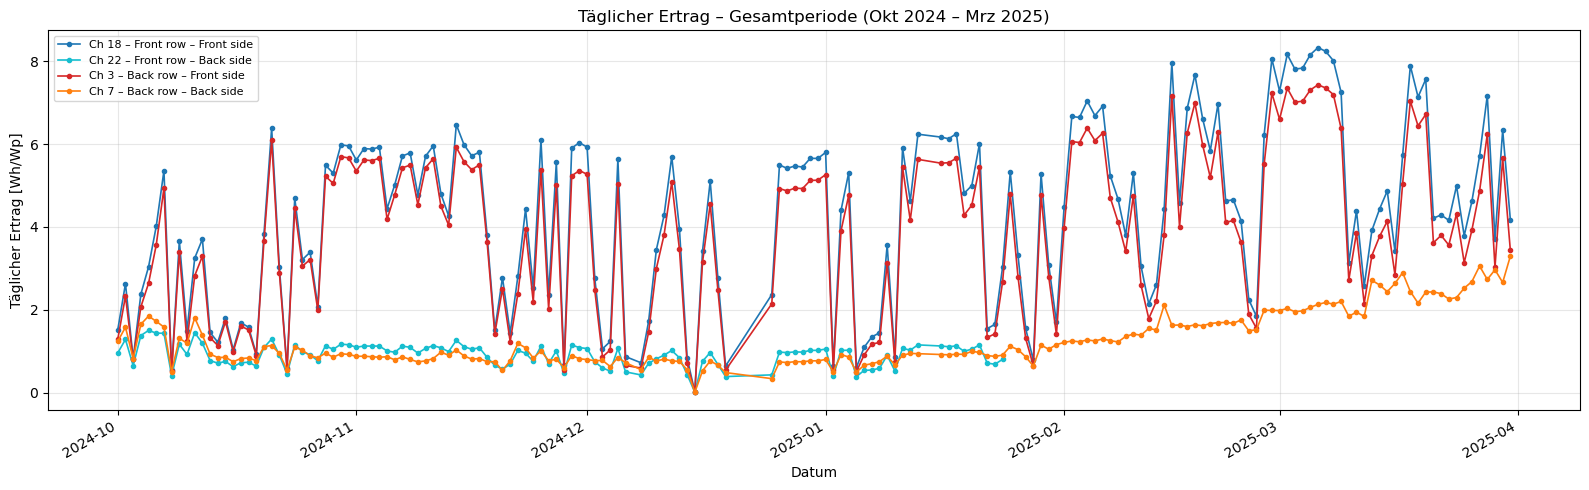

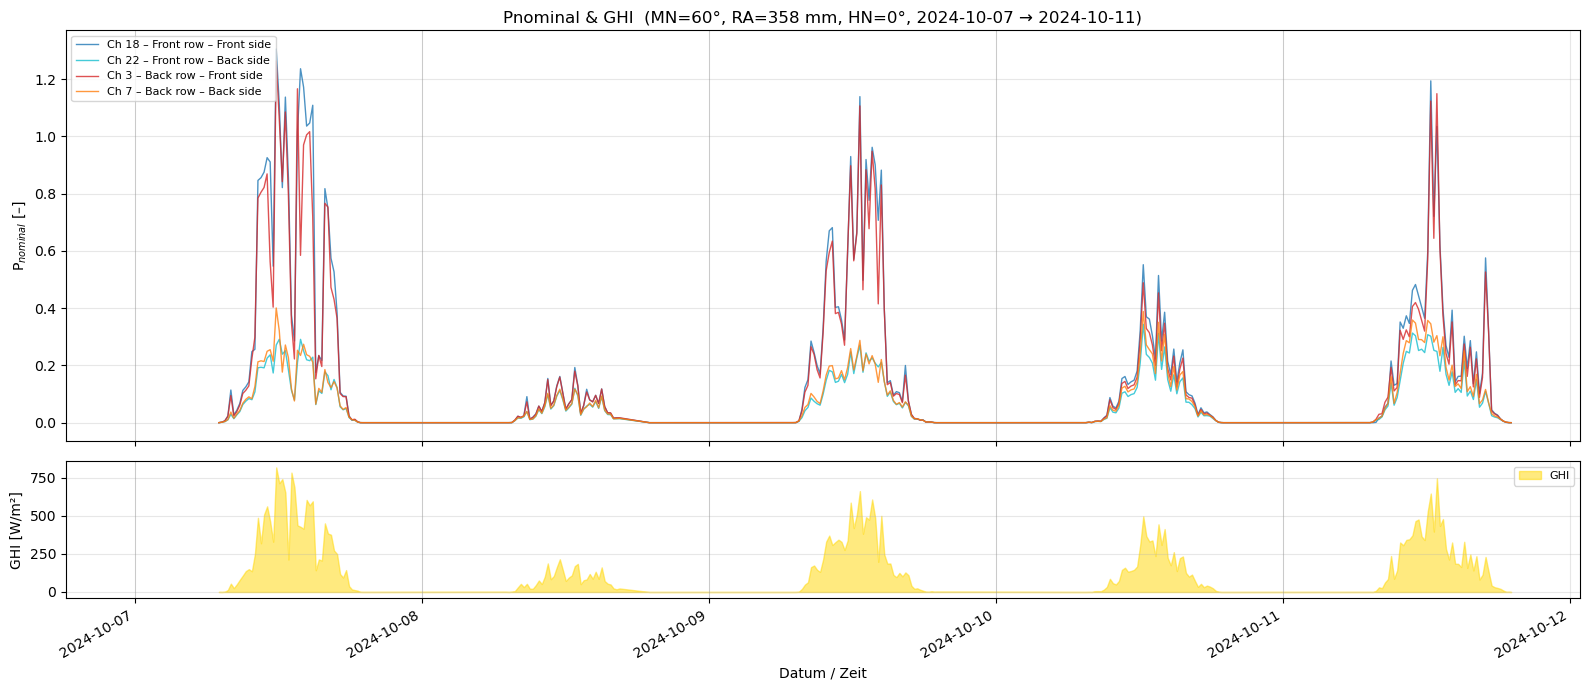

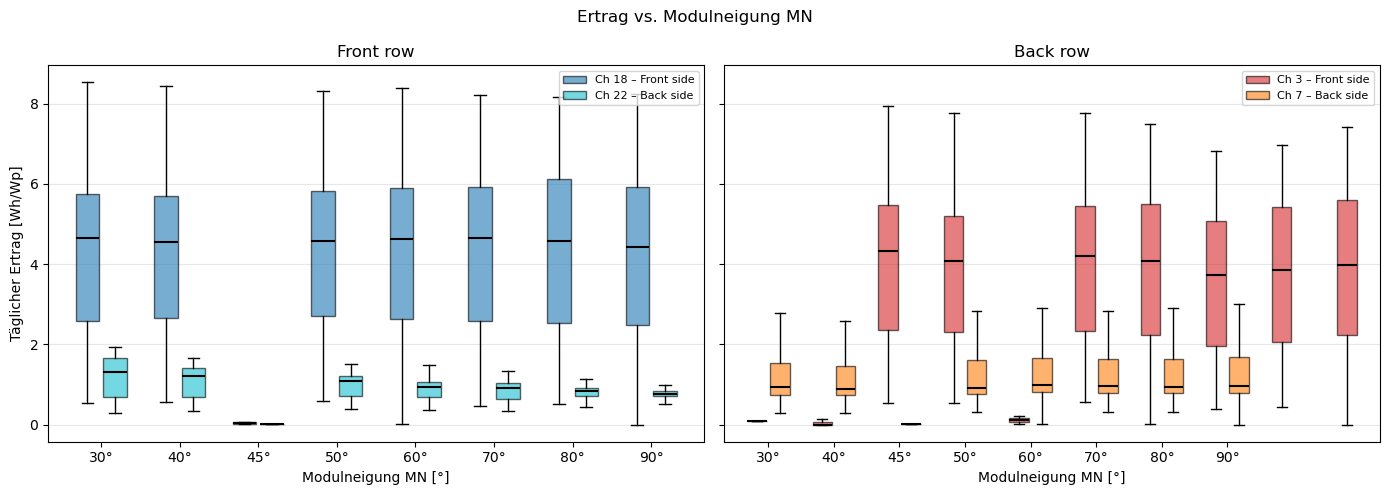

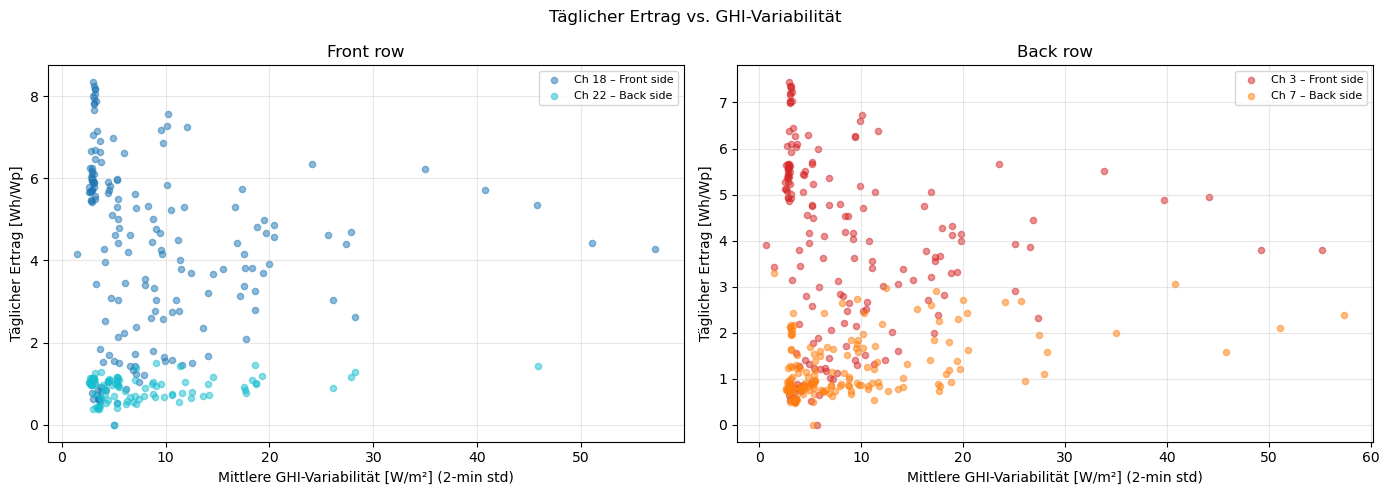

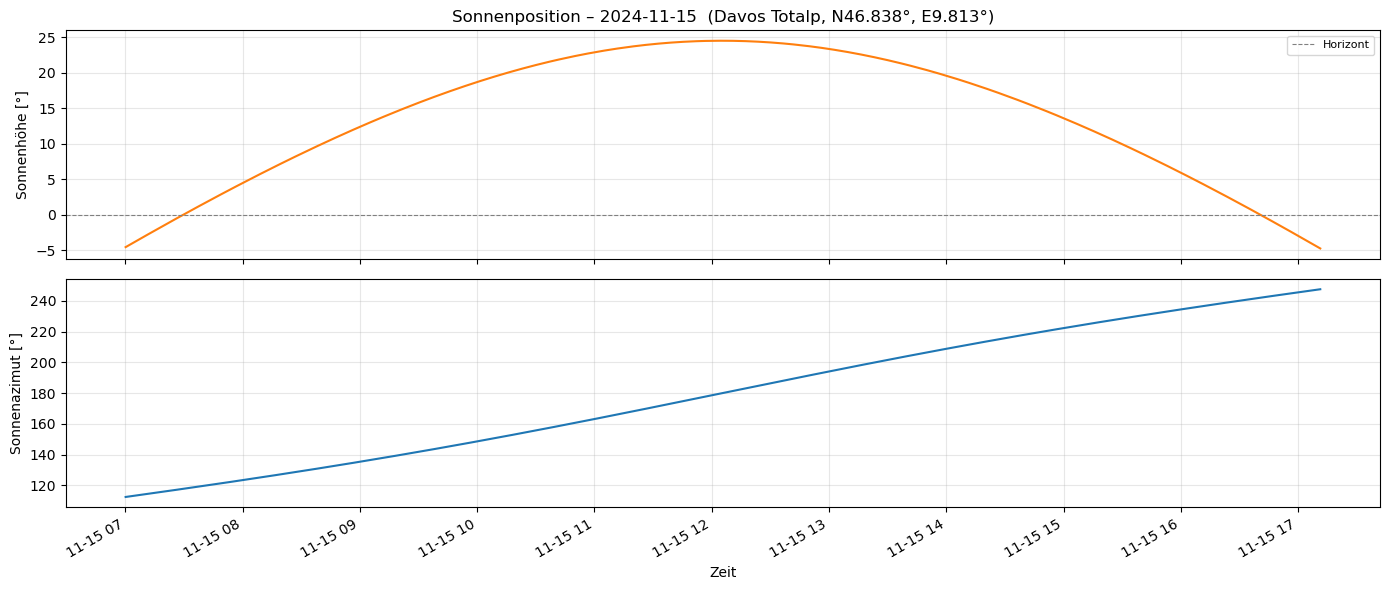

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# 10. VISUALISIERUNGEN
# ═══════════════════════════════════════════════════════════════════════════════

df_rel = combined[combined['channel'].isin(RELEVANT_CHANNELS.keys())].copy()

# ── Plot 1: Täglicher Ertrag über Gesamtperiode ───────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

for ch, label in RELEVANT_CHANNELS.items():
    daily = calculate_daily_yield(df_rel, ch)
    if len(daily) > 0:
        ax.plot(pd.to_datetime(daily['date']), daily['yield_Wh_Wp'],
                marker='o', ms=3, lw=1.2, color=COLORS[ch], label=f'Ch {ch} – {label}')

ax.set_ylabel('Täglicher Ertrag [Wh/Wp]')
ax.set_xlabel('Datum')
ax.set_title('Täglicher Ertrag – Gesamtperiode (Okt 2024 – Mrz 2025)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# ── Plot 2: Pnominal Zeitreihe + GHI über mehrere Tage ───────────────────────
# Konfiguration wählen
MN_SEL, RA_SEL, HN_SEL = 60, 358, 0
DATE_START, DATE_END = '2024-10-07', '2024-10-11'   # Beispielwoche

df_plot = filter_combined(df_rel, MN=MN_SEL, RA=RA_SEL, HN=HN_SEL,
                          date_start=DATE_START, date_end=DATE_END,
                          sun_up_only=False)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax_pv, ax_ghi = axes

for ch, label in RELEVANT_CHANNELS.items():
    grp = df_plot[df_plot['channel'] == ch].sort_values('mes_date')
    ax_pv.plot(grp['mes_date'], grp['Pnominal'],
               lw=1.0, alpha=0.8, color=COLORS[ch], label=f'Ch {ch} – {label}')

ax_pv.set_ylabel('P$_{nominal}$ [–]')
ax_pv.set_title(f'Pnominal & GHI  (MN={MN_SEL}°, RA={RA_SEL} mm, HN={HN_SEL}°, '
                f'{DATE_START} → {DATE_END})')
ax_pv.legend(fontsize=8)
ax_pv.grid(True, alpha=0.3)

# GHI aus env_interp direkt aus df_plot
ghi_plot = df_plot[df_plot['channel'] == 18].sort_values('mes_date')
ax_ghi.fill_between(ghi_plot['mes_date'], ghi_plot['GHI'],
                    alpha=0.5, color='gold', label='GHI')
ax_ghi.set_ylabel('GHI [W/m²]')
ax_ghi.set_xlabel('Datum / Zeit')
ax_ghi.legend(fontsize=8)
ax_ghi.grid(True, alpha=0.3)

# Tagesgrenzen markieren
for date in pd.date_range(DATE_START, DATE_END, freq='D', tz=TZ):
    ax_pv.axvline(date, color='grey', lw=0.5, alpha=0.4)
    ax_ghi.axvline(date, color='grey', lw=0.5, alpha=0.4)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# ── Plot 3: Ertrag vs. MN-Winkel (Boxplot) ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (ch_front, ch_back), row_name in zip(
    axes, [(18, 22), (3, 7)], ['Front row', 'Back row']
):
    for ch, style, label_side in [
        (ch_front, dict(color=COLORS[ch_front]), 'Front side'),
        (ch_back,  dict(color=COLORS[ch_back]),  'Back side'),
    ]:
        mn_yields = {}
        for mn in sorted(df_rel['MN'].unique()):
            daily = calculate_daily_yield(df_rel, ch, MN=mn)
            if len(daily) > 0:
                mn_yields[mn] = daily['yield_Wh_Wp'].values

        mn_labels = sorted(mn_yields.keys())
        data = [mn_yields[mn] for mn in mn_labels]
        positions = [i + (0 if ch == ch_front else 0.35)
                     for i in range(len(mn_labels))]

        bp = ax.boxplot(data, positions=positions, widths=0.3,
                        patch_artist=True, showfliers=False,
                        medianprops=dict(color='black', lw=1.5))
        for patch in bp['boxes']:
            patch.set_facecolor(style['color'])
            patch.set_alpha(0.6)
        bp['boxes'][0].set_label(f'Ch {ch} – {label_side}')

    ax.set_xticks([i + 0.175 for i in range(len(mn_labels))])
    ax.set_xticklabels([f'{mn}°' for mn in mn_labels])
    ax.set_xlabel('Modulneigung MN [°]')
    ax.set_title(f'{row_name}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

axes[0].set_ylabel('Täglicher Ertrag [Wh/Wp]')
fig.suptitle('Ertrag vs. Modulneigung MN', fontsize=12)
plt.tight_layout()
plt.show()

# ── Plot 4: Ertrag vs. GHI-Variabilität (Scatter) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (ch_front, ch_back), row_name in zip(
    axes, [(18, 22), (3, 7)], ['Front row', 'Back row']
):
    for ch, label_side in [(ch_front, 'Front side'), (ch_back, 'Back side')]:
        daily = calculate_daily_yield(df_rel, ch)
        if len(daily) == 0:
            continue

        # Mittlere GHI-Variabilität pro Tag
        ghi_daily = (
            df_rel[df_rel['channel'] == ch]
            .assign(date=lambda x: x['mes_date'].dt.date)
            .groupby('date')['GHI_std_2min']
            .mean()
            .reset_index()
        )
        merged = daily.merge(ghi_daily, on='date', how='inner')

        ax.scatter(merged['GHI_std_2min'], merged['yield_Wh_Wp'],
                   alpha=0.5, s=20, color=COLORS[ch],
                   label=f'Ch {ch} – {label_side}')

    ax.set_xlabel('Mittlere GHI-Variabilität [W/m²] (2-min std)')
    ax.set_ylabel('Täglicher Ertrag [Wh/Wp]')
    ax.set_title(f'{row_name}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Täglicher Ertrag vs. GHI-Variabilität', fontsize=12)
plt.tight_layout()
plt.show()

# ── Plot 5: Sonnenposition (Elevation & Azimuth) ──────────────────────────────
# Beispieltag für Sonnenposition
EXAMPLE_DATE = '2024-11-15'

sol_day = combined[
    (combined['mes_date'].dt.date == pd.Timestamp(EXAMPLE_DATE).date()) &
    (combined['channel'] == 18)
].sort_values('mes_date')

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax_el, ax_az = axes

ax_el.plot(sol_day['mes_date'], sol_day['solar_elevation'],
           color='tab:orange', lw=1.5)
ax_el.axhline(0, color='grey', lw=0.8, linestyle='--', label='Horizont')
ax_el.set_ylabel('Sonnenhöhe [°]')
ax_el.set_title(f'Sonnenposition – {EXAMPLE_DATE}  (Davos Totalp, N{LAT}°, E{LON}°)')
ax_el.legend(fontsize=8)
ax_el.grid(True, alpha=0.3)

ax_az.plot(sol_day['mes_date'], sol_day['solar_azimuth'],
           color='tab:blue', lw=1.5)
ax_az.set_ylabel('Sonnenazimut [°]')
ax_az.set_xlabel('Zeit')
ax_az.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()